In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.lines as mlines
import os
import matplotlib.patches as mpatches
import sys

parent_dir = "/Users/yalilyu/Desktop/result/"
sys.path.append(parent_dir)

from utils.lipinskiness import lipinskiness
from rdkit import DataStructs
from rdkit.Chem import MACCSkeys
from rdkit.Chem import Draw
from rdkit import Chem
from rdkit.Chem.rdmolfiles import MolToSmarts, MolFromSmiles, MolFromSmarts

In [2]:
ar_mast3 = {}

for k in ['005','01','02','03']:
    key = f"ar_l4_k{k}"
    file_path = f"ar_l4_k{k}.csv"

    if os.path.exists(file_path):
        print(file_path)
        ar_mast3[key] = pd.read_csv(file_path, sep="\s+", header=None)
        ar_mast3[key].columns = ["time","smiles", "lip_sc", "docking_sc"]
        ar_mast3[key].index = range(1, len(ar_mast3[key]) +1)

ar_l4_k005.csv
ar_l4_k01.csv
ar_l4_k02.csv
ar_l4_k03.csv


In [3]:
her2_mast3 = {}

for k in ['005','01','02','03']:
    key = f"her2_l4_k{k}"
    file_path = f"her2_l4_k{k}.csv"

    if os.path.exists(file_path):
        print(file_path)
        her2_mast3[key] = pd.read_csv(file_path, sep="\s+", header=None)
        her2_mast3[key].columns = ["time","smiles", "lip_sc", "docking_sc"]
        her2_mast3[key].index = range(1, len(her2_mast3[key]) +1)

her2_l4_k005.csv
her2_l4_k01.csv
her2_l4_k02.csv
her2_l4_k03.csv


In [4]:
db_toadd = {}
db = {}

for protein in ['ar','her2']:
    for i in [1,2,3]:
        key = f"{protein}_l4_r{i}"
        file_path = f"../result_0707/newngram/{protein}_l4_r{i}.csv"
        
        if os.path.exists(file_path):
            print(file_path)
            db_toadd[key] = pd.read_csv(file_path, sep="\s+", header=None)
            db_toadd[key].columns = ["time","smiles", "lip_sc", "docking_sc"]
            db_toadd[key].index = range(1, len(db_toadd[key]) +1)
        else:
            continue

for protein in ['ar','her2']:
        key = f"{protein}"
        key1 = f"{protein}_l4_r1"
        key2 = f"{protein}_l4_r2"
        key3 = f"{protein}_l4_r3"
        if key1 in db_toadd and key2 in db_toadd:
            db[key] = pd.concat([db_toadd[key1], db_toadd[key2], db_toadd[key3]], axis=0)
        elif key1 in db_toadd:
            db[key] = db_toadd[key1]
        elif key2 in db_toadd:
            db[key] = db_toadd[key2]
        elif key3 in db_toadd:
            db[key] = db_toadd[key3]
        else:
            print(f"Neither {key1} nor {key2} nor {key3} found.")

../result_0707/newngram/ar_l4_r1.csv
../result_0707/newngram/ar_l4_r2.csv
../result_0707/newngram/ar_l4_r3.csv
../result_0707/newngram/her2_l4_r1.csv
../result_0707/newngram/her2_l4_r2.csv
../result_0707/newngram/her2_l4_r3.csv


In [5]:
ar_mast3['no_mast'] = db['ar']
her2_mast3['no_mast'] = db['her2']

In [6]:
for key, df in ar_mast3.items():
    ar_mast3[key] = df[(df['lip_sc'] != -2.0) & (df['docking_sc']!= 1000.0)]

In [7]:
for key, df in her2_mast3.items():
    her2_mast3[key] = df[(df['lip_sc'] != -2.0) & (df['docking_sc']!= 1000.0)]

In [8]:
for key in ['no_mast','ar_l4_k005','ar_l4_k01','ar_l4_k02','ar_l4_k03']:
    # Sample 1000 random rows without replacement
    sample_of_ar_mast = ar_mast3[key].iloc[:500]
    ar_mast3[key] = sample_of_ar_mast

In [9]:
for key in ['no_mast','her2_l4_k005','her2_l4_k01','her2_l4_k02','her2_l4_k03']:
    # Sample 1000 random rows without replacement
    sample_of_her2_mast = her2_mast3[key].iloc[:500]
    her2_mast3[key] = sample_of_her2_mast

In [10]:
for k_value, df in ar_mast3.items():
    num_mol = len(df)
    print(f"Number of molecules generated by ar mast {k_value} is {num_mol}")

Number of molecules generated by ar mast ar_l4_k005 is 500
Number of molecules generated by ar mast ar_l4_k01 is 500
Number of molecules generated by ar mast ar_l4_k02 is 500
Number of molecules generated by ar mast ar_l4_k03 is 500
Number of molecules generated by ar mast no_mast is 500


In [11]:
for k_value, df in her2_mast3.items():
    num_mol = len(df)
    print(f"Number of molecules generated by her2 mast {k_value} is {num_mol}")

Number of molecules generated by her2 mast her2_l4_k005 is 500
Number of molecules generated by her2 mast her2_l4_k01 is 500
Number of molecules generated by her2 mast her2_l4_k02 is 498
Number of molecules generated by her2 mast her2_l4_k03 is 500
Number of molecules generated by her2 mast no_mast is 500


dict_values([2.0, 2.0, 2.0])
Highest Tanimoto similarity score (AR): 0.586


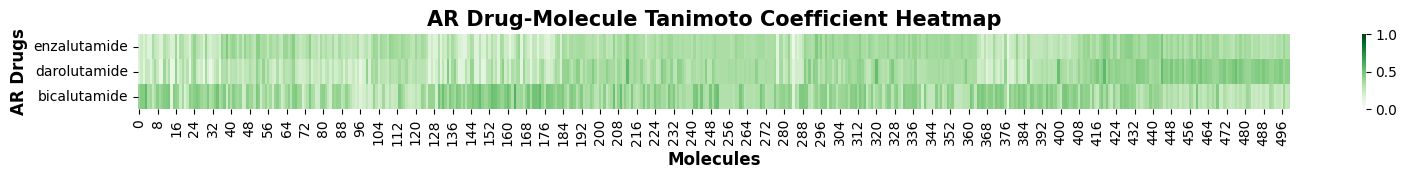

Average Tanimoto score for AR-targeting molecules: 0.410
Std Dev: 0.061


In [12]:
ar_smiles = ar_mast3['ar_l4_k03'].smiles.to_list()



ar_drug_name = ['enzalutamide', 'darolutamide', 'bicalutamide']

ar_drug_dir = {'enzalutamide':'CC1(C(=O)N(C(=S)N1C2=CC(=C(C=C2)C(=O)NC)F)C3=CC(=C(C=C3)C#N)C(F)(F)F)C', 
               'darolutamide': 'CC(CN1C=CC(=N1)C2=CC(=C(C=C2)C#N)Cl)NC(=O)C3=NNC(=C3)C(C)O', 
               'bicalutamide': 'CC(CS(=O)(=O)C1=CC=C(C=C1)F)(C(=O)NC2=CC(=C(C=C2)C#N)C(F)(F)F)O'}

ar_drug_dock = {'enzalutamide': -6.8, 
               'darolutamide': -8.5, 
               'bicalutamide': -9.8}

ar_drug_lip = {}
for key, smiles in ar_drug_dir.items():
    lip_sc = lipinskiness(smiles)
    ar_drug_lip[key] = lip_sc
print(ar_drug_lip.values())

# Convert SMILES to molecules and fingerprints
ar_drugs = [Chem.MolFromSmiles(smile) for smile in ar_drug_dir.values()]
ar_drug_fps = [MACCSkeys.GenMACCSKeys(mol) for mol in ar_drugs]

ar_mols = [Chem.MolFromSmiles(smile) for smile in ar_smiles]
ar_mol_fps = [MACCSkeys.GenMACCSKeys(mol) for mol in ar_mols]

# Calculate similarity matrix
similarity_matrix_ar = np.zeros((len(ar_drugs), len(ar_mols)))
for i in range(len(ar_drugs)):
    for j in range(len(ar_mols)):
        score = DataStructs.TanimotoSimilarity(ar_drug_fps[i], ar_mol_fps[j])
        similarity_matrix_ar[i, j] = score

# Max similarity score
max_score_ar = np.max(similarity_matrix_ar)
print(f"Highest Tanimoto similarity score (AR): {max_score_ar:.3f}")

# Plot heatmap for AR
plt.figure(figsize=(16, 1))
sns.heatmap(similarity_matrix_ar, annot=False, fmt=".2f", cmap='Greens', vmin=0, vmax=1,
            yticklabels=[f'{key}' for key in ar_drug_dir.keys()])
plt.xlabel('Molecules', fontsize=12, fontweight='bold')
plt.ylabel('AR Drugs', fontsize=12, fontweight='bold')
plt.title('AR Drug-Molecule Tanimoto Coefficient Heatmap', fontsize=15, fontweight='bold')
plt.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.2)
plt.show()

# Compute maximum similarity scores for each molecule
ar_tani_score = []
for i in range(len(ar_mols)):
    score = 0
    for j in range(len(ar_drugs)):
        tani_score = DataStructs.TanimotoSimilarity(ar_drug_fps[j], ar_mol_fps[i])
        if tani_score > score:
            score = tani_score
    ar_tani_score.append(score)
ar_tani_score = np.array(ar_tani_score)
print(f"Average Tanimoto score for AR-targeting molecules: {ar_tani_score.mean():.3f}")
print(f"Std Dev: {ar_tani_score.std():.3f}")

dict_values([])
Highest Tanimoto similarity score (HER2): 0.714


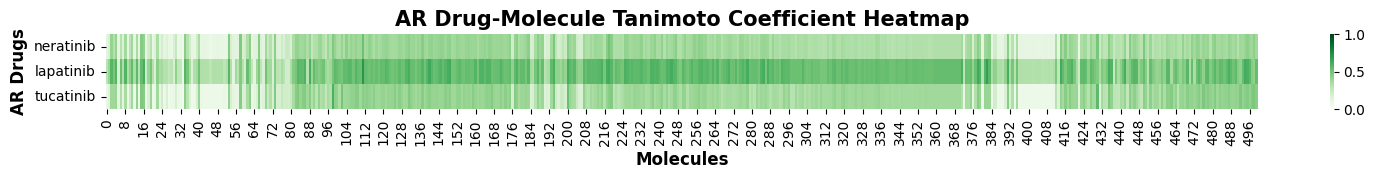

Average Tanimoto score for HER2-targeting molecules: 0.485
Std Dev: 0.102


In [13]:
her2_smiles = her2_mast3['her2_l4_k01'].smiles.to_list()



her2_drug_name = ['neratinib', 'lapatinib', 'tucatinib']

her2_drug_dir = {'neratinib':'CCOC1=C(C=C2C(=C1)N=CC(=C2NC3=CC(=C(C=C3)OCC4=CC=CC=N4)Cl)C#N)NC(=O)C=CCN(C)C', 
               'lapatinib': 'CS(=O)(=O)CCNCC1=CC=C(O1)C2=CC3=C(C=C2)N=CN=C3NC4=CC(=C(C=C4)OCC5=CC(=CC=C5)F)Cl', 
               'tucatinib': 'CC1=C(C=CC(=C1)NC2=NC=NC3=C2C=C(C=C3)NC4=NC(CO4)(C)C)OC5=CC6=NC=NN6C=C5'}

her2_drug_dock = {'neratinib': -8.5, 
               'lapatinib': -9.7, 
               'tucatinib': -10.6}

her2_drug_lip = {}
for key, smiles in her2_drug_dir.items():
    lip_sc = lipinskiness(smiles)
    ar_drug_lip[key] = lip_sc
print(her2_drug_lip.values())

# Convert SMILES to molecules and fingerprints
her2_drugs = [Chem.MolFromSmiles(smile) for smile in her2_drug_dir.values()]
her2_drug_fps = [MACCSkeys.GenMACCSKeys(mol) for mol in her2_drugs]

her2_mols = [Chem.MolFromSmiles(smile) for smile in her2_smiles]
her2_mol_fps = [MACCSkeys.GenMACCSKeys(mol) for mol in her2_mols]

# Calculate similarity matrix
similarity_matrix_her2 = np.zeros((len(her2_drugs), len(her2_mols)))
for i in range(len(her2_drugs)):
    for j in range(len(her2_mols)):
        score = DataStructs.TanimotoSimilarity(her2_drug_fps[i], her2_mol_fps[j])
        similarity_matrix_her2[i, j] = score

# Max similarity score
max_score_her2 = np.max(similarity_matrix_her2)
print(f"Highest Tanimoto similarity score (HER2): {max_score_her2:.3f}")

# Plot heatmap for AR
plt.figure(figsize=(16, 1))
sns.heatmap(similarity_matrix_her2, annot=False, fmt=".2f", cmap='Greens', vmin=0, vmax=1,
            yticklabels=[f'{key}' for key in her2_drug_dir.keys()])
plt.xlabel('Molecules', fontsize=12, fontweight='bold')
plt.ylabel('AR Drugs', fontsize=12, fontweight='bold')
plt.title('AR Drug-Molecule Tanimoto Coefficient Heatmap', fontsize=15, fontweight='bold')
plt.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.2)
plt.show()

# Compute maximum similarity scores for each molecule
her2_tani_score = []
for i in range(len(her2_mols)):
    score = 0
    for j in range(len(her2_drugs)):
        tani_score = DataStructs.TanimotoSimilarity(her2_drug_fps[j], her2_mol_fps[i])
        if tani_score > score:
            score = tani_score
    her2_tani_score.append(score)
her2_tani_score = np.array(her2_tani_score)
print(f"Average Tanimoto score for HER2-targeting molecules: {her2_tani_score.mean():.3f}")
print(f"Std Dev: {her2_tani_score.std():.3f}")

/var/folders/7h/31w4d6n52ds2j9y7fxh5ngjc0000gn/T/ipykernel_8517/2390598928.py:55: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1,0].legend(title='', loc='upper left', bbox_to_anchor=(1,1))
/var/folders/7h/31w4d6n52ds2j9y7fxh5ngjc0000gn/T/ipykernel_8517/2390598928.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1,0].legend().set_visible(False)
/var/folders/7h/31w4d6n52ds2j9y7fxh5ngjc0000gn/T/ipykernel_8517/2390598928.py:64: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1,1].legend().set_visible(False)  # Hide duplicate legend
/var/folders/7h/31w4d6n52ds2j9y7fxh5ngjc0000gn/T/ipykernel_8517/239059

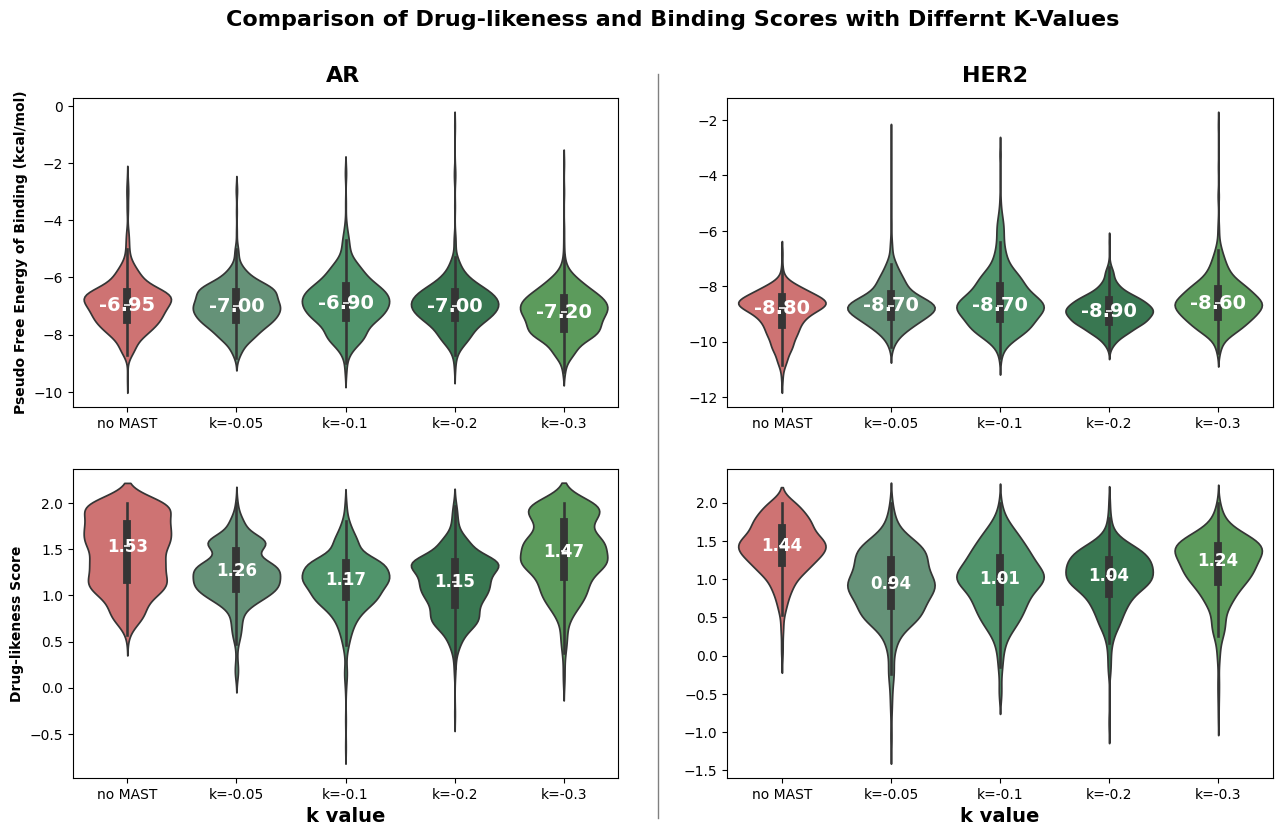

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


# Prepare data for AR and HER2
datasets = ['no_mast', 'ar_l4_k005', 'ar_l4_k01', 'ar_l4_k02', 'ar_l4_k03']
her2_keys = ['no_mast','her2_l4_k005', 'her2_l4_k01', 'her2_l4_k02', 'her2_l4_k03']
k_labels = ['no MAST', 'k=-0.05', 'k=-0.1', 'k=-0.2', 'k=-0.3']

# Function to prepare DataFrame
def prepare_df(keys, label_prefix):
    data_list = []
    for k, label in zip(keys, k_labels[0:]):
        df = globals()[label_prefix][k]  # e.g., ar_mast3 or her2_mast3
        for col in ['lip_sc', 'docking_sc']:
            temp = pd.DataFrame({
                'value': df[col],
                'dataset': label,
                'k': label,
                'sc_type': col
            })
            data_list.append(temp)
    return pd.concat(data_list, ignore_index=True)

# Assuming HER2 data is in variables named 'her2_mast3' similar to 'ar_mast3'
# Prepare dataframes for AR and HER2
ar_data = prepare_df(datasets, 'ar_mast3')
her2_data = prepare_df(her2_keys, 'her2_mast3')

# Filter for scores
ar_lip = ar_data[ar_data['sc_type'] == 'lip_sc']
ar_dock = ar_data[ar_data['sc_type'] == 'docking_sc']

her2_lip = her2_data[her2_data['sc_type'] == 'lip_sc']
her2_dock = her2_data[her2_data['sc_type'] == 'docking_sc']

# Set up the 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(15, 8))

# Define color palette for datasets
dataset_palette = {
    'no MAST': "#dd6464",
    'k=-0.2': "#2f814f",
    'k=-0.3': "#51a651",
    'k=-0.1': "#459f69",
    'k=-0.05': "#5d9a77"
}

# Top Left: AR Drug-like Scores
sns.violinplot(x='k', y='value', hue='dataset', data=ar_lip, ax=axes[1,0], palette=dataset_palette, split=False)
# axes[1,0].set_title('Drug-likeness Score',fontsize=14)
axes[1,0].set_ylabel('Drug-likeness Score',fontweight='bold')
axes[1,0].set_xlabel('k value',fontweight='bold',fontsize=14)
axes[1,0].legend(title='', loc='upper left', bbox_to_anchor=(1,1))
axes[1,0].legend().set_visible(False)

# Top Right: HER2 Drug-like Scores
sns.violinplot(x='k', y='value', hue='dataset', data=her2_lip, ax=axes[1,1], palette=dataset_palette, split=False)
# axes[1,1].set_title('Drug-likeness Score',fontsize=14)
axes[1,1].set_xlabel('k value',fontweight='bold',fontsize=14)
axes[1,1].set_ylabel('')
axes[1,1].set_xlabel('k value',fontweight='bold',fontsize=14)
axes[1,1].legend().set_visible(False)  # Hide duplicate legend

# Bottom Left: AR Binding Scores
sns.violinplot(x='k', y='value', hue='dataset', data=ar_dock, ax=axes[0,0], palette=dataset_palette, split=False)
# axes[0,0].set_title('Binding Score',fontsize=14,fontweight='bold')
axes[0,0].set_xlabel('')
axes[0,0].set_ylabel('Pseudo Free Energy of Binding (kcal/mol)',fontweight='bold')
axes[0,0].legend().set_visible(False)

# Bottom Right: HER2 Binding Scores
sns.violinplot(x='k', y='value', hue='dataset', data=her2_dock, ax=axes[0,1], palette=dataset_palette, split=False)
# axes[0,1].set_title('Binding Score',fontsize=14,fontweight='bold')
axes[0,1].set_ylabel('')
axes[0,1].set_xlabel('')
axes[0,1].legend().set_visible(False)

# Adding median labels for each violin in the drug-like plot
for ax, data in zip(axes[1, :], [ar_lip, her2_lip]):
    for i, k_label in enumerate(k_labels[0:]):
        subset = data[data['k'] == k_label]
        for dataset_name in subset['dataset'].unique():
            median_value = subset[subset['dataset'] == dataset_name]['value'].median()
            # Place median text at the center of the violin (roughly at x=i)
            ax.text(i, median_value, f'{median_value:.2f}', ha='center', va='center', fontweight='bold',fontsize=12,  color='white')

# Adding median labels for each violin in the binding plot
for ax, data in zip(axes[0, :], [ar_dock, her2_dock]):
    for i, k_label in enumerate(k_labels[0:]):
        subset = data[data['k'] == k_label]
        for dataset_name in subset['dataset'].unique():
            median_value = subset[subset['dataset'] == dataset_name]['value'].median()
            ax.text(i, median_value, f'{median_value:.2f}', ha='center', va='center', fontweight='bold',fontsize=14, color='white')

# Add column labels "AR" and "HER2" above columns
fig.text(0.28, 0.92, 'AR', ha='center', fontsize=16, fontweight='bold')
fig.text(0.715, 0.92, 'HER2', ha='center', fontsize=16, fontweight='bold')

# for ax in [axes[0,0], axes[0,1]]:
#     rect = plt.Rectangle((ax.get_xlim()[0], ax.get_ylim()[0]),
#                          width=ax.get_xlim()[1] - ax.get_xlim()[0],
#                          height=ax.get_ylim()[1] - ax.get_ylim()[0],
#                          linewidth=2, edgecolor='brown', facecolor='none', zorder=10)
#     ax.add_patch(rect)

plt.suptitle("Comparison of Drug-likeness and Binding Scores with Differnt K-Values", fontsize=16,y=1.01,fontweight='bold')
plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.05, hspace=0.2)
import matplotlib.lines as mlines
line = mlines.Line2D([0.49, 0.49], [0.0, 0.93], transform=plt.gcf().transFigure,
                     color='grey', linewidth=1)
plt.gcf().add_artist(line)
# Show plot
plt.show()


In [15]:
ar_medians = {}
for key, df in ar_mast3.items():
    n_mols = len(df)
    medians = []

    for s in range(0,n_mols):
        e = s + 1
        chunk = df['docking_sc'].iloc[:e]
        median_value = chunk.median()
        medians.append(median_value)
    ar_medians[key]=medians
    print(f"median for {key}, is {medians}")

median for ar_l4_k005, is [-6.4, -6.65, -6.4, -6.65, -6.9, -6.65, -6.9, -6.95, -7.0, -7.2, -7.3, -7.35, -7.4, -7.35, -7.3, -7.35, -7.4, -7.35, -7.4, -7.35, -7.3, -7.3, -7.3, -7.3, -7.3, -7.25, -7.2, -7.15, -7.2, -7.15, -7.1, -7.15, -7.1, -7.15, -7.1, -7.1, -7.1, -7.1, -7.1, -7.15, -7.2, -7.2, -7.2, -7.25, -7.3, -7.3, -7.3, -7.3, -7.3, -7.3, -7.3, -7.3, -7.3, -7.3, -7.3, -7.3, -7.3, -7.3, -7.3, -7.3, -7.3, -7.3, -7.3, -7.3, -7.3, -7.3, -7.3, -7.3, -7.3, -7.3, -7.3, -7.3, -7.3, -7.3, -7.3, -7.3, -7.3, -7.35, -7.4, -7.35, -7.3, -7.3, -7.3, -7.3, -7.3, -7.35, -7.4, -7.35, -7.4, -7.35, -7.3, -7.3, -7.3, -7.3, -7.3, -7.3, -7.3, -7.3, -7.3, -7.3, -7.3, -7.3, -7.3, -7.3, -7.3, -7.3, -7.3, -7.3, -7.3, -7.3, -7.3, -7.3, -7.3, -7.3, -7.3, -7.3, -7.3, -7.3, -7.3, -7.3, -7.3, -7.3, -7.3, -7.3, -7.3, -7.3, -7.3, -7.3, -7.3, -7.25, -7.2, -7.2, -7.2, -7.2, -7.2, -7.2, -7.2, -7.2, -7.2, -7.2, -7.2, -7.2, -7.2, -7.2, -7.2, -7.15, -7.1, -7.1, -7.1, -7.1, -7.1, -7.1, -7.1, -7.1, -7.1, -7.1, -7.1, -7.1, -7

In [16]:
her2_medians = {}
for key, df in her2_mast3.items():
    n_mols = len(df)
    medians = []

    for s in range(0,n_mols):
        e = s + 1
        chunk = df['docking_sc'].iloc[:e]
        median_value = chunk.median()
        medians.append(median_value)
    her2_medians[key]=medians
    print(f"median for {key}, is {medians}")

median for her2_l4_k005, is [-8.7, -8.45, -8.7, -8.55, -8.7, -8.55, -8.7, -8.899999999999999, -8.7, -8.55, -8.4, -8.3, -8.2, -8.3, -8.2, -8.2, -8.2, -8.2, -8.2, -8.1, -8.2, -8.149999999999999, -8.2, -8.149999999999999, -8.1, -8.149999999999999, -8.1, -8.149999999999999, -8.2, -8.2, -8.2, -8.2, -8.2, -8.2, -8.2, -8.2, -8.2, -8.3, -8.4, -8.4, -8.4, -8.4, -8.4, -8.45, -8.5, -8.45, -8.5, -8.5, -8.5, -8.55, -8.6, -8.55, -8.6, -8.6, -8.6, -8.6, -8.6, -8.6, -8.6, -8.6, -8.6, -8.6, -8.6, -8.6, -8.6, -8.6, -8.6, -8.6, -8.6, -8.6, -8.6, -8.6, -8.6, -8.6, -8.6, -8.6, -8.6, -8.6, -8.6, -8.6, -8.6, -8.6, -8.6, -8.6, -8.6, -8.55, -8.5, -8.5, -8.5, -8.5, -8.5, -8.5, -8.5, -8.5, -8.5, -8.5, -8.5, -8.5, -8.5, -8.5, -8.5, -8.5, -8.5, -8.5, -8.5, -8.5, -8.5, -8.5, -8.5, -8.5, -8.5, -8.45, -8.4, -8.45, -8.5, -8.5, -8.5, -8.45, -8.5, -8.45, -8.4, -8.4, -8.4, -8.4, -8.4, -8.4, -8.4, -8.4, -8.4, -8.4, -8.4, -8.4, -8.4, -8.4, -8.4, -8.4, -8.4, -8.4, -8.4, -8.4, -8.4, -8.4, -8.4, -8.45, -8.4, -8.45, -8.5, -8.4

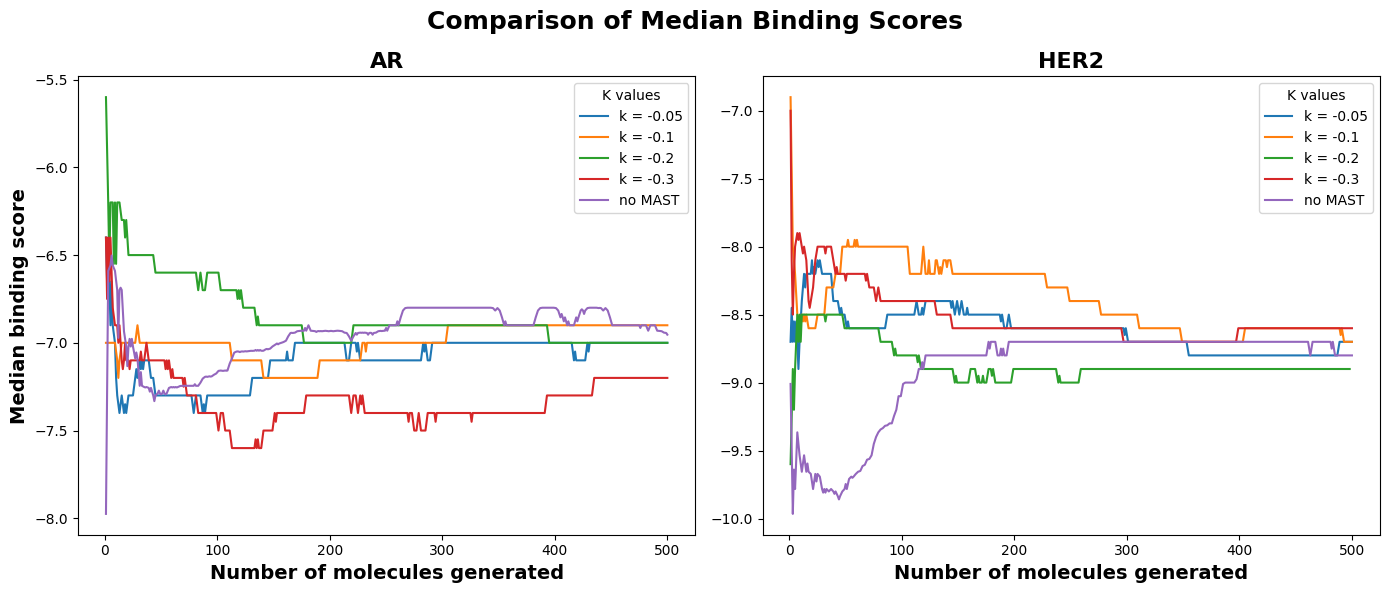

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Define labels for each line for both plots
labels = ['k = -0.05', 'k = -0.1', 'k = -0.2', 'k = -0.3', 'no MAST']

# Plot for ar_medians
for label, (key, medians) in zip(labels, list(ar_medians.items())):
    indices = range(1, len(medians) + 1)
    sns.lineplot(x=indices, y=medians, ax=axes[0], label=label)
axes[0].set_title('AR',fontweight='bold', fontsize=16)
axes[0].set_xlabel('Number of molecules generated',fontweight='bold',fontsize=14)
axes[0].set_ylabel('Median binding score',fontweight='bold',fontsize=14)
axes[0].legend(title='K values')
axes[0].grid(False)  # Optional: remove grid

# Plot for her2_medians
for label, (key, medians) in zip(labels, her2_medians.items()):
    indices = range(1, len(medians) + 1)
    sns.lineplot(x=indices, y=medians, ax=axes[1], label=label)
axes[1].set_title('HER2',fontweight='bold', fontsize=16)
axes[1].set_xlabel('Number of molecules generated',fontweight='bold',fontsize=14)
axes[1].legend(title='K values')
axes[1].grid(False)  # Optional: remove grid
plt.suptitle('Comparison of Median Binding Scores', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()


In [18]:
import numpy as np
from scipy.stats import mannwhitneyu

# Define the list of datasets and their labels
datasets = ['no_mast', 'ar_l4_k005', 'ar_l4_k01', 'ar_l4_k02', 'ar_l4_k03']
labels = ['no MAST', 'k=-0.05', 'k=-0.1', 'k=-0.2', 'k=-0.3']

# Prepare data: assuming ar_mast3 is a dict containing data for each key
# For both 'lip_sc' (drug likeness) and 'docking_sc' (binding scores)

# Initialize dictionaries to store p-values
p_values_drug_likeness = {}
p_values_binding = {}

# Loop over all pairs of datasets
for i in range(len(datasets)):
    for j in range(i + 1, len(datasets)):
        dataset_i = datasets[i]
        dataset_j = datasets[j]
        label_i = labels[i]
        label_j = labels[j]
        key_i = dataset_i
        key_j = dataset_j
        
        # Extract scores for 'lip_sc'
        data_i_lip = ar_mast3[key_i]['lip_sc']
        data_j_lip = ar_mast3[key_j]['lip_sc']
        # Mann-Whitney test for drug likeness
        stat, p_val_lip = mannwhitneyu(data_i_lip, data_j_lip, alternative='two-sided')
        p_values_drug_likeness[f"{label_i} vs {label_j}"] = p_val_lip
        
        # Extract scores for 'docking_sc'
        data_i_dock = ar_mast3[key_i]['docking_sc']
        data_j_dock = ar_mast3[key_j]['docking_sc']
        # Mann-Whitney test for binding scores
        stat, p_val_dock = mannwhitneyu(data_i_dock, data_j_dock, alternative='two-sided')
        p_values_binding[f"{label_i} vs {label_j}"] = p_val_dock

# Output the results
print("P-values for drug likeness comparisons:")
for comparison, p in p_values_drug_likeness.items():
    print(f"{comparison}: {p:3e}")

print("\nP-values for binding score comparisons:")
for comparison, p in p_values_binding.items():
    print(f"{comparison}: {p:.3e}")


P-values for drug likeness comparisons:
no MAST vs k=-0.05: 2.304598e-21
no MAST vs k=-0.1: 1.369783e-37
no MAST vs k=-0.2: 8.166676e-41
no MAST vs k=-0.3: 8.663187e-01
k=-0.05 vs k=-0.1: 3.398019e-06
k=-0.05 vs k=-0.2: 1.045900e-07
k=-0.05 vs k=-0.3: 2.919528e-23
k=-0.1 vs k=-0.2: 3.820252e-01
k=-0.1 vs k=-0.3: 2.492145e-41
k=-0.2 vs k=-0.3: 3.846414e-43

P-values for binding score comparisons:
no MAST vs k=-0.05: 5.142e-01
no MAST vs k=-0.1: 5.071e-02
no MAST vs k=-0.2: 8.205e-01
no MAST vs k=-0.3: 4.930e-08
k=-0.05 vs k=-0.1: 7.406e-03
k=-0.05 vs k=-0.2: 6.205e-01
k=-0.05 vs k=-0.3: 1.323e-06
k=-0.1 vs k=-0.2: 2.526e-02
k=-0.1 vs k=-0.3: 2.569e-12
k=-0.2 vs k=-0.3: 1.086e-07


In [19]:
import numpy as np
from scipy.stats import mannwhitneyu

# Define the list of datasets and their labels
datasets = ['no_mast', 'her2_l4_k005', 'her2_l4_k01', 'her2_l4_k02', 'her2_l4_k03']
labels = ['no MAST', 'k=-0.05', 'k=-0.1', 'k=-0.2', 'k=-0.3']

# Prepare data: assuming ar_mast3 is a dict containing data for each key
# For both 'lip_sc' (drug likeness) and 'docking_sc' (binding scores)

# Initialize dictionaries to store p-values
p_values_drug_likeness = {}
p_values_binding = {}

# Loop over all pairs of datasets
for i in range(len(datasets)):
    for j in range(i + 1, len(datasets)):
        dataset_i = datasets[i]
        dataset_j = datasets[j]
        label_i = labels[i]
        label_j = labels[j]
        key_i = dataset_i
        key_j = dataset_j
        
        # Extract scores for 'lip_sc'
        data_i_lip = her2_mast3[key_i]['lip_sc']
        data_j_lip = her2_mast3[key_j]['lip_sc']
        # Mann-Whitney test for drug likeness
        stat, p_val_lip = mannwhitneyu(data_i_lip, data_j_lip, alternative='two-sided')
        p_values_drug_likeness[f"{label_i} vs {label_j}"] = p_val_lip
        
        # Extract scores for 'docking_sc'
        data_i_dock = her2_mast3[key_i]['docking_sc']
        data_j_dock = her2_mast3[key_j]['docking_sc']
        # Mann-Whitney test for binding scores
        stat, p_val_dock = mannwhitneyu(data_i_dock, data_j_dock, alternative='two-sided')
        p_values_binding[f"{label_i} vs {label_j}"] = p_val_dock

# Output the results
print("P-values for drug likeness comparisons:")
for comparison, p in p_values_drug_likeness.items():
    print(f"{comparison}: {p:3e}")

print("\nP-values for binding score comparisons:")
for comparison, p in p_values_binding.items():
    print(f"{comparison}: {p:.3e}")


P-values for drug likeness comparisons:
no MAST vs k=-0.05: 1.005788e-64
no MAST vs k=-0.1: 2.316660e-55
no MAST vs k=-0.2: 4.412897e-61
no MAST vs k=-0.3: 2.558661e-24
k=-0.05 vs k=-0.1: 5.680588e-02
k=-0.05 vs k=-0.2: 2.473826e-03
k=-0.05 vs k=-0.3: 2.526227e-19
k=-0.1 vs k=-0.2: 2.852229e-01
k=-0.1 vs k=-0.3: 4.988088e-13
k=-0.2 vs k=-0.3: 2.882998e-13

P-values for binding score comparisons:
no MAST vs k=-0.05: 7.671e-05
no MAST vs k=-0.1: 3.861e-08
no MAST vs k=-0.2: 4.537e-01
no MAST vs k=-0.3: 4.050e-10
k=-0.05 vs k=-0.1: 1.449e-01
k=-0.05 vs k=-0.2: 3.483e-07
k=-0.05 vs k=-0.3: 2.847e-02
k=-0.1 vs k=-0.2: 4.527e-09
k=-0.1 vs k=-0.3: 6.725e-01
k=-0.2 vs k=-0.3: 1.721e-12
